In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Titanic test dataset
df = pd.read_csv("tested.csv")

# Map numeric Survived/Not Survived values to labels
survival_names = {0: 'Not Survived', 1: 'Survived'}
df['Survived_label'] = df['Survived'].map(survival_names)

In [3]:
print("First 5 Rows")
df.head()

First 5 Rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived_label
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Not Survived
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Survived
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Not Survived
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Not Survived
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Survived


In [4]:
print("\nShape of Dataset")
df.shape


Shape of Dataset


(418, 13)

In [5]:
print("\nColumn Names")
df.columns


Column Names


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Survived_label'],
      dtype='object')

In [6]:
print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PassengerId     418 non-null    int64  
 1   Survived        418 non-null    int64  
 2   Pclass          418 non-null    int64  
 3   Name            418 non-null    object 
 4   Sex             418 non-null    object 
 5   Age             332 non-null    float64
 6   SibSp           418 non-null    int64  
 7   Parch           418 non-null    int64  
 8   Ticket          418 non-null    object 
 9   Fare            417 non-null    float64
 10  Cabin           91 non-null     object 
 11  Embarked        418 non-null    object 
 12  Survived_label  418 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 42.6+ KB


In [7]:
print("\nStatistical Summary")
df.describe()


Statistical Summary


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
print("\nMissing Values")
df.isnull().sum()


Missing Values


PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                86
SibSp               0
Parch               0
Ticket              0
Fare                1
Cabin             327
Embarked            0
Survived_label      0
dtype: int64

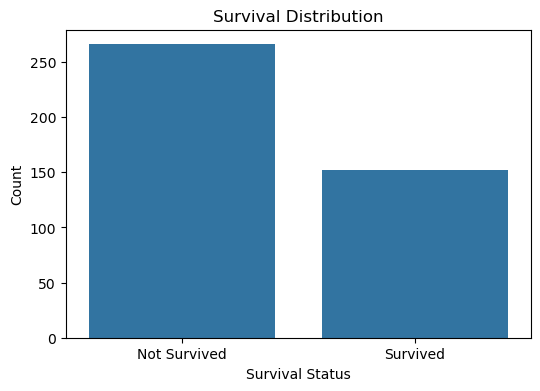

In [9]:
# Count plot showing how many passengers survived vs did not
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived_label', data=df)
plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Count")
plt.show()

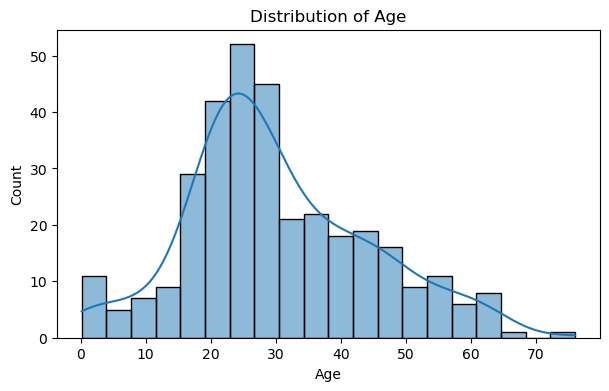

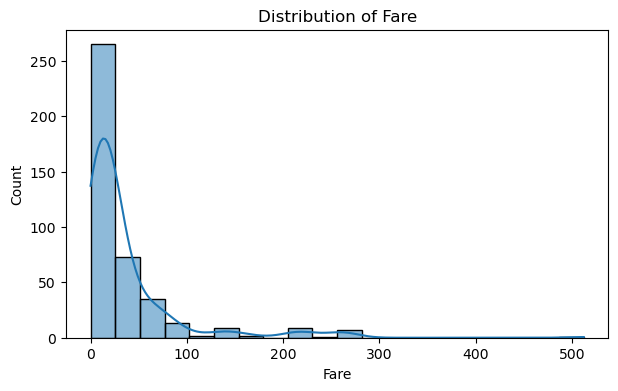

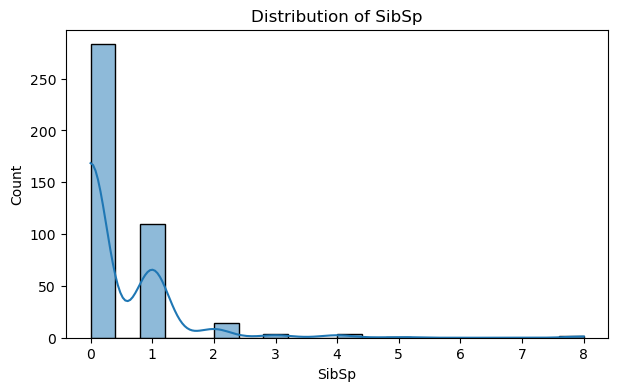

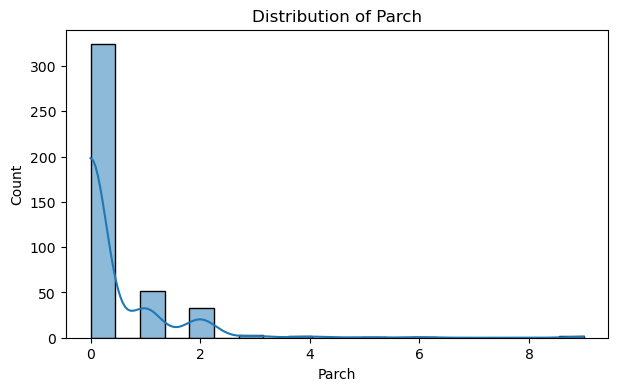

In [10]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

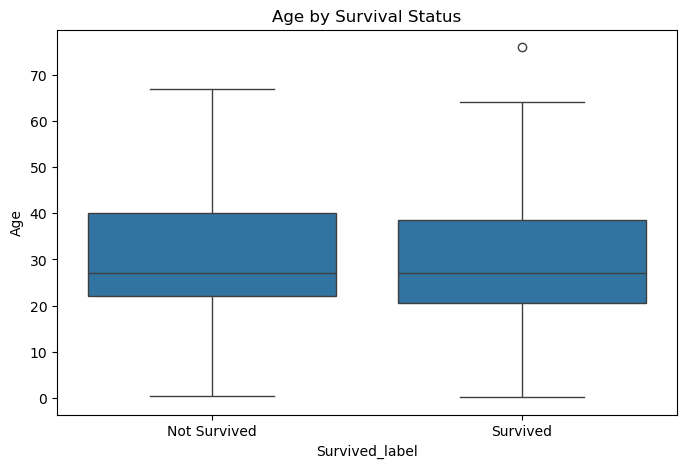

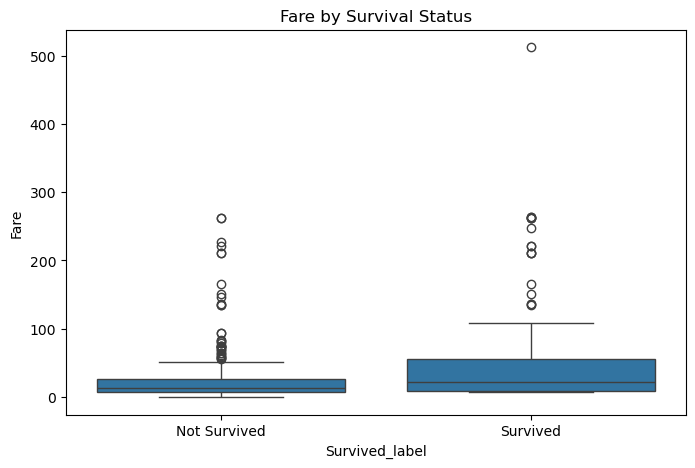

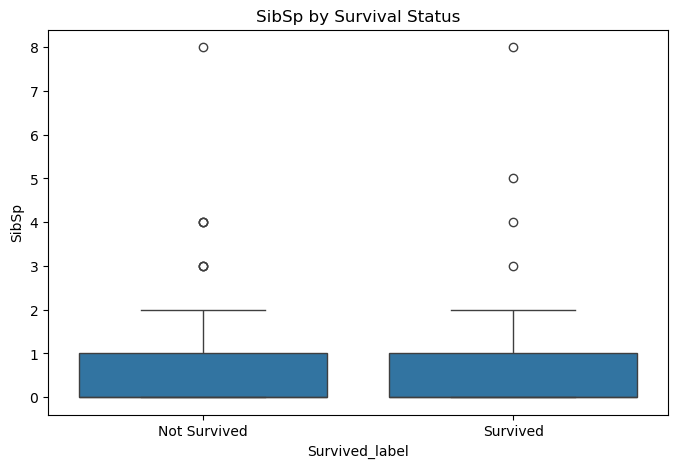

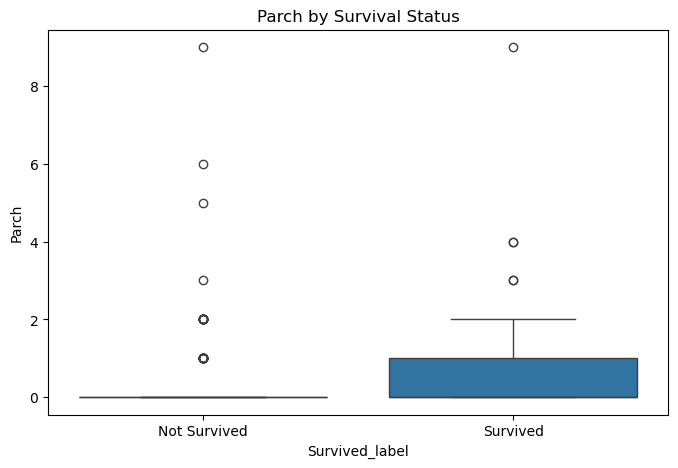

In [11]:
# Boxplots 
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Survived_label', y=col, data=df)
    plt.title(f"{col} by Survival Status")
    plt.show()

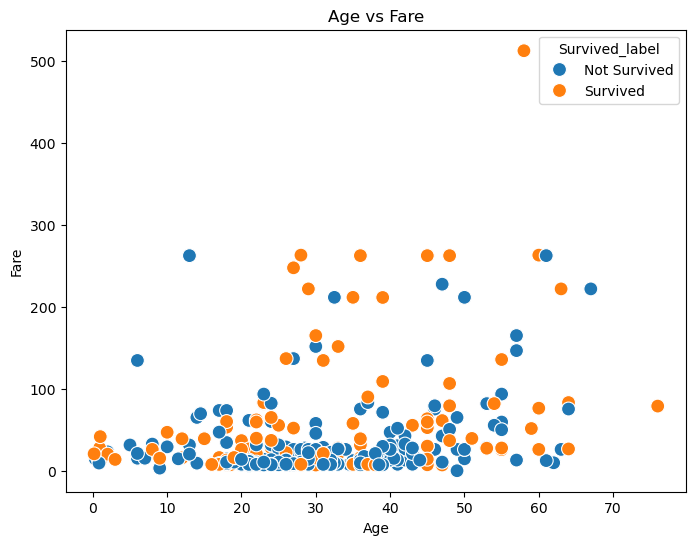

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Age',
    y='Fare',
    hue='Survived_label',
    data=df,
    s=100
)
plt.title("Age vs Fare")
plt.show()

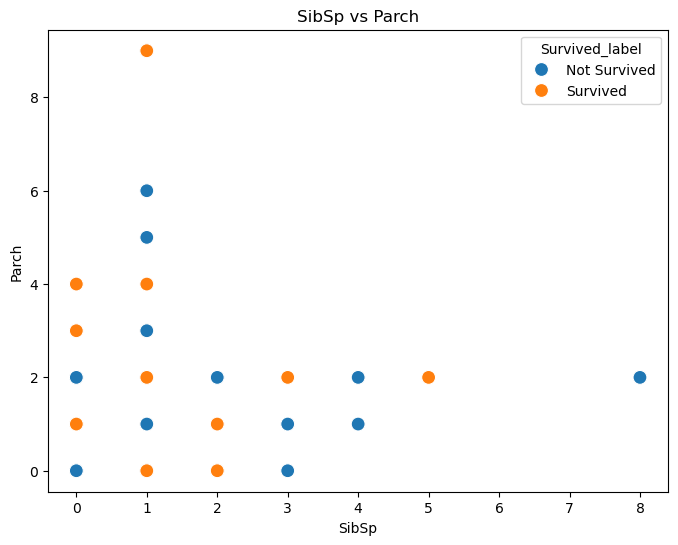

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='SibSp',
    y='Parch',
    hue='Survived_label',
    data=df,
    s=100
)
plt.title("SibSp vs Parch")
plt.show()

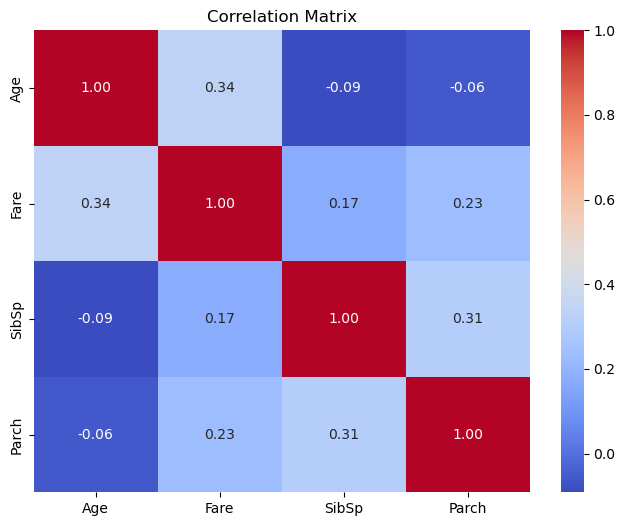

In [14]:
# Correlation heatmap for numerical
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()

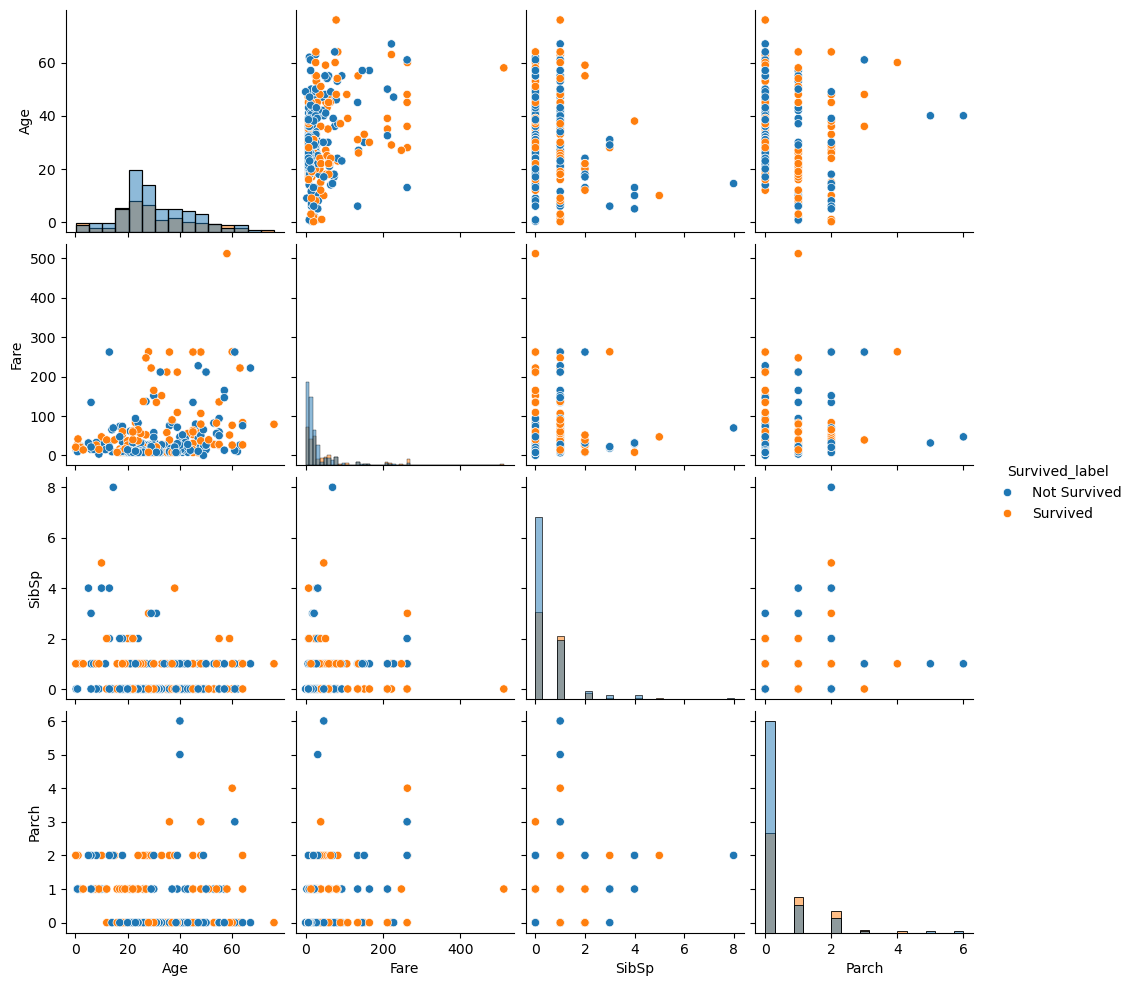

In [15]:
# Pairplot
sns.pairplot(
    df[numerical_cols + ['Survived_label']].dropna(),
    hue='Survived_label',
    diag_kind='hist'
)
plt.show()